In [1]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode
y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

I0000 00:00:1776168667.236925     242 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776168669.358524     242 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776168675.554095     242 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_val, y_val),
    verbose=2
)

/home/d8cc4292-e27e-4552-add6-e900bb876820/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1776168684.013059     242 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5


W0000 00:00:1776168686.321172     242 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


1500/1500 - 18s - 12ms/step - accuracy: 0.8418 - loss: 0.4426 - val_accuracy: 0.8857 - val_loss: 0.3270
Epoch 2/5
1500/1500 - 17s - 11ms/step - accuracy: 0.8939 - loss: 0.2983 - val_accuracy: 0.8898 - val_loss: 0.3110
Epoch 3/5
1500/1500 - 19s - 13ms/step - accuracy: 0.9072 - loss: 0.2572 - val_accuracy: 0.8993 - val_loss: 0.2846
Epoch 4/5
1500/1500 - 17s - 11ms/step - accuracy: 0.9167 - loss: 0.2295 - val_accuracy: 0.9068 - val_loss: 0.2614
Epoch 5/5
1500/1500 - 24s - 16ms/step - accuracy: 0.9256 - loss: 0.2050 - val_accuracy: 0.9098 - val_loss: 0.2575


In [4]:
test_loss_base, test_acc_base = baseline_model.evaluate(x_test, y_test)
print("Baseline Test Accuracy:", test_acc_base)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9012 - loss: 0.2730
Baseline Test Accuracy: 0.901199996471405


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

improved_model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3,3), activation='relu',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [8]:
history_improved = improved_model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/10


I0000 00:00:1776168787.585945     242 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


750/750 - 84s - 112ms/step - accuracy: 0.7044 - loss: 1.0864 - val_accuracy: 0.8136 - val_loss: 0.7255
Epoch 2/10
750/750 - 64s - 86ms/step - accuracy: 0.7778 - loss: 0.7937 - val_accuracy: 0.8353 - val_loss: 0.6188
Epoch 3/10
750/750 - 63s - 85ms/step - accuracy: 0.8004 - loss: 0.7037 - val_accuracy: 0.8680 - val_loss: 0.5124
Epoch 4/10
750/750 - 56s - 74ms/step - accuracy: 0.8095 - loss: 0.6642 - val_accuracy: 0.8563 - val_loss: 0.5282
Epoch 5/10
750/750 - 57s - 76ms/step - accuracy: 0.8177 - loss: 0.6453 - val_accuracy: 0.8482 - val_loss: 0.5546
Epoch 6/10
750/750 - 55s - 74ms/step - accuracy: 0.8206 - loss: 0.6312 - val_accuracy: 0.8367 - val_loss: 0.5657
Epoch 7/10
750/750 - 82s - 110ms/step - accuracy: 0.8251 - loss: 0.6301 - val_accuracy: 0.8469 - val_loss: 0.5469
Epoch 8/10
750/750 - 630s - 839ms/step - accuracy: 0.8281 - loss: 0.6206 - val_accuracy: 0.8266 - val_loss: 0.5834


In [9]:
test_loss_imp, test_acc_imp = improved_model.evaluate(x_test, y_test, verbose=2)
print("Improved Test Accuracy:", test_acc_imp)

313/313 - 24s - 76ms/step - accuracy: 0.8580 - loss: 0.5311
Improved Test Accuracy: 0.8579999804496765


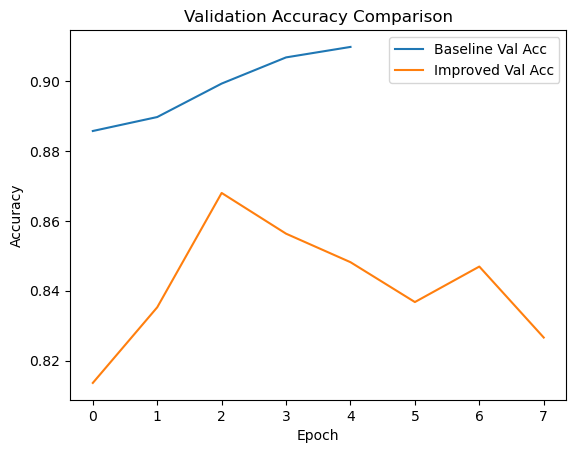

In [10]:
import matplotlib.pyplot as plt

plt.plot(history_baseline.history['val_accuracy'], label='Baseline Val Acc')
plt.plot(history_improved.history['val_accuracy'], label='Improved Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

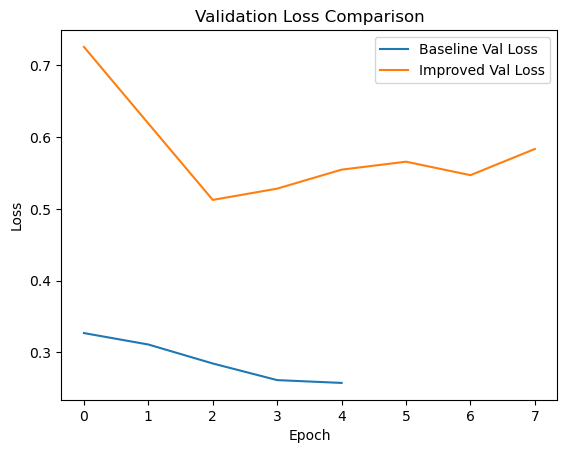

In [11]:
plt.plot(history_baseline.history['val_loss'], label='Baseline Val Loss')
plt.plot(history_improved.history['val_loss'], label='Improved Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

The comparison of both accuracy and loss shows clear differences between the baseline and improved models. The baseline model achieved higher accuracy and lower validation loss, indicating a stronger fit to the data. However, the improved model, which included dropout, L2 regularization, batch normalization, data augmentation, and early stopping, showed a different pattern. Its validation loss decreased early in training but then began to increase, suggesting that the model reached its optimal point quickly and that additional training did not improve performance. This reflects the impact of early stopping and regularization, which prevented the model from overfitting but also limited its ability to achieve higher accuracy. Overall, the techniques helped control overfitting, but in this case they were somewhat too strong, leading to lower overall performance compared to the baseline.